# Regime Classification — What Each War Phase Actually Looks Like

**Goal:** turn the 6 war phases from a set of dated labels into a quantified *reference table* — for each regime, the typical level and spread of every key variable in the warehouse (Brent, USD/INR, FII net flow, Nifty return, 10Y G-Sec, CPI/WPI).

**Why this comes first in Milestone 3:** the stress index (Component 2) is built on *deviations from the pre-war baseline*, and the historical benchmarking (Component 3) compares regimes across episodes. Both need an agreed, reproducible answer to "what is normal in each regime" rather than re-deriving phase characteristics from scratch each time.

**This is descriptive, not modelling.** No new estimation happens here — it is a grouped summarisation of `india_stress_panel`, in the same spirit as the phase-level aggregates in Milestone 2's `analytics_queries.sql`.

**Reproducibility:** every number below comes from three saved views in **`sql/regime_summary.sql`** (`regime_summary`, `regime_summary_detail`, `regime_dynamics`). This notebook only reads and presents them — re-run `load_warehouse.py` and re-execute, and the table updates itself against refreshed data.

In [1]:
import sys
from pathlib import Path
# find the project root (dir containing src/etl/config.py) and import our DB helper
_p = Path.cwd()
for _c in [_p, *_p.parents]:
    if (_c / 'src' / 'etl' / 'config.py').exists():
        sys.path.insert(0, str(_c / 'src' / 'etl')); ROOT = _c; break
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import config
engine = config.get_engine()
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
pd.set_option('display.width', 200)
print('connected to', config.DB_NAME)

connected to war_shock_lab


In [2]:
# The headline reference table: one row per regime, one column per variable (phase means).
rs = pd.read_sql('SELECT * FROM regime_summary ORDER BY phase_id', engine)
num = [c for c in rs.columns if c not in ('phase_name','start_date','end_date')]
rs[num] = rs[num].apply(pd.to_numeric)
rs.set_index('phase_id')[['phase_name','start_date','end_date','n_trading_days',
                          'brent_avg_usd','usd_inr_avg','fii_avg_daily_cr',
                          'nifty_ret_avg_pct','nifty_vol_daily_pct',
                          'gsec_10y_avg_pct','gsec_n_obs','cpi_avg_pct','wpi_avg_pct']]

,phase_name,start_date,end_date,n_trading_days,brent_avg_usd,usd_inr_avg,fii_avg_daily_cr,nifty_ret_avg_pct,nifty_vol_daily_pct,gsec_10y_avg_pct,gsec_n_obs,cpi_avg_pct,wpi_avg_pct
phase_id,,,,,,,,,,,,,
1,Pre-war baseline,2026-01-01,2026-02-27,40,67.150,90.732,-342.000,-0.094,0.777,NaN,0,2.980,1.970
2,Acute war I,2026-03-02,2026-04-07,23,100.550,92.737,"-7,415.000",-0.357,1.582,NaN,0,3.414,4.659
3,First ceasefire,2026-04-08,2026-04-10,3,95.290,92.535,"-3,423.000",1.337,2.357,NaN,0,3.480,8.360
4,Naval blockade / brinkmanship,2026-04-13,2026-06-12,42,101.350,95.003,"-2,582.000",-0.039,0.842,7.030,10,3.898,9.317
5,MoU / de-escalation,2026-06-15,2026-07-06,15,75.920,94.855,"1,100.000",0.226,0.606,7.020,15,4.380,9.870
6,Renewed conflict,2026-07-07,2026-07-31,19,86.520,96.082,906.000,-0.007,0.777,6.884,19,4.380,9.870


**Conclusion — the six regimes are quantitatively distinct, and they line up with the narrative:**

- **Phase 1 (pre-war)** is the control: Brent **$67**, rupee **90.7**, FII essentially flat (**−₹342 cr/day**), Nifty daily volatility **0.78%**. This is the reference distribution the stress index will normalise against.
- **Phase 2 (acute war)** is the shock: Brent jumps to **$100.6** (+50% vs baseline), FII selling explodes to **−₹7,415 cr/day** (21× the baseline rate), Nifty averages **−0.36%/day** and volatility **doubles to 1.58%**. Every variable moves in the same direction at once — that co-movement is exactly what a composite index is meant to capture.
- **Phase 3 (first ceasefire)** is a 3-day relief bounce (**+1.34%/day**), but with the *highest* volatility of any regime (2.36%) — relief and fear, not calm. **Only 3 trading days: treat every phase-3 statistic as indicative, not estimated.**
- **Phase 4 (naval blockade)** is the grind: the **highest average Brent of the whole war ($101.4, peak $118)** and the weakest average rupee to that point (95.0), yet Nifty is nearly flat (−0.04%/day) at low volatility (0.84%). The market has stopped repricing the shock daily and is holding a level — a *different* stress regime from phase 2 despite similar oil.
- **Phase 5 (MoU / de-escalation)** is the release: Brent collapses to **$75.9** and FII turns **net buyer (+₹1,100 cr/day)** — the only positive-flow regime up to that point.
- **Phase 6 (renewed conflict)** re-escalates oil (**$86.5**, from $74 to $90 across the phase) and pushes the rupee to its weakest average (**96.1**), but equities are flat and **foreign flows stay positive (+₹906 cr/day)**. Oil-and-currency stress without an equity or flow response — a genuinely new regime signature, not a repeat of phase 2.

**On coverage — `gsec_n_obs` is in the table on purpose.** The 10Y G-Sec column shows **0 observations for phases 1–3**: only 3 yield values have ever been published into this warehouse (first on 2026-05-31). Those cells are NULL by construction, not zero and not filled. This is the gap flagged as a blocker for Component 2 — the stress index's bond-yield component cannot be normalised against a pre-war baseline that has no observations in it.

In [3]:
# Same data in long form, with a spread measure. mean ± 1 sd per (phase, variable).
det = pd.read_sql('SELECT * FROM regime_summary_detail ORDER BY var_order, phase_id', engine)
for c in ['n_days','n_obs','mean_val','sd_val','min_val','max_val']:
    det[c] = pd.to_numeric(det[c])

def cell_mean_sd(r):
    if r.n_obs == 0:
        return 'no data'
    return f'{r.mean_val:,.2f} ± {r.sd_val:,.2f}'

det['mean_sd'] = det.apply(cell_mean_sd, axis=1)
spread = det.pivot(index=['var_order','variable','unit'], columns='phase_id', values='mean_sd')
spread.columns = [f'P{c}' for c in spread.columns]
spread.reset_index(level='var_order', drop=True)

,,P1,P2,P3,P4,P5,P6
variable,unit,,,,,,
brent,USD/bbl,67.15 ± 3.46,100.55 ± 10.06,95.29 ± 0.59,101.35 ± 7.61,75.92 ± 3.75,86.52 ± 7.07
usd_inr,INR per USD,90.73 ± 0.57,92.74 ± 0.96,92.53 ± 0.30,95.00 ± 1.02,94.86 ± 0.39,96.08 ± 0.48
fii_net_flow,INR crore/day,"-342.00 ± 3,040.00","-7,415.00 ± 3,954.00","-3,423.00 ± 2,952.00","-2,582.00 ± 4,507.00","1,100.00 ± 1,868.00","906.00 ± 3,322.00"
nifty_return,% per day,-0.09 ± 0.78,-0.36 ± 1.58,1.34 ± 2.36,-0.04 ± 0.84,0.23 ± 0.61,-0.01 ± 0.78
gsec_10y_yield,% yield,no data,no data,no data,7.03 ± 0.00,7.02 ± 0.01,6.88 ± 0.11
cpi,% YoY (ffilled),2.98 ± 0.23,3.41 ± 0.03,3.48 ± 0.00,3.90 ± 0.34,4.38 ± 0.00,4.38 ± 0.00
wpi,% YoY (ffilled),1.97 ± 0.16,4.66 ± 1.74,8.36 ± 0.00,9.32 ± 0.65,9.87 ± 0.00,9.87 ± 0.00


**Conclusion — the spread matters as much as the mean.** Reading `mean ± sd` rather than the mean alone changes two readings:

- **FII flow is not just lower in wartime, it is wilder.** Baseline is −342 ± 3,040 cr; the blockade phase is −2,582 ± **4,507** cr with a single worst day of **−₹21,949 cr**. A phase can have a modest average and still contain the largest outflow days in the dataset — an index built on levels alone would miss that, which is why the stress index normalises by the baseline *standard deviation*, not just the baseline mean.
- **Acute war has the widest Brent dispersion** (100.55 ± 10.06, range $77.74–$112.78) — the price was being violently re-discovered. The blockade phase has a *higher* mean but a tighter spread (101.35 ± 7.61): the market had settled on a war-price level.

The `no data` cells for G-Sec in phases 1–3 make the coverage gap structural rather than something a reader has to infer from a suspicious-looking zero.

In [4]:
# The observed range per regime (min–max), and the observation count behind each figure.
rng = det.copy()
rng['range'] = rng.apply(lambda r: 'no data' if r.n_obs == 0
                         else f'{r.min_val:,.2f} … {r.max_val:,.2f}  (n={int(r.n_obs)}/{int(r.n_days)})', axis=1)
rng.pivot(index=['var_order','variable','unit'], columns='phase_id',
          values='range').set_axis([f'P{c}' for c in sorted(det.phase_id.unique())], axis=1) \
   .reset_index(level='var_order', drop=True)

,,P1,P2,P3,P4,P5,P6
variable,unit,,,,,,
brent,USD/bbl,59.96 … 72.48 (n=37/40),77.74 … 112.78 (n=23/23),94.75 … 95.92 (n=3/3),87.33 … 118.03 (n=41/42),71.57 … 83.17 (n=13/15),74.16 … 100.69 (n=19/19)
usd_inr,INR per USD,89.86 … 92.04 (n=39/40),91.08 … 94.78 (n=23/23),92.28 … 92.86 (n=3/3),92.60 … 96.57 (n=42/42),94.33 … 95.53 (n=15/15),95.33 … 96.88 (n=19/19)
fii_net_flow,INR crore/day,"-6,093.00 … 7,561.00 (n=39/40)","-19,837.00 … -1,566.00 (n=21/23)","-6,810.00 … -1,396.00 (n=3/3)","-21,949.00 … 3,099.00 (n=42/42)","-1,807.00 … 5,527.00 (n=15/15)","-3,428.00 … 9,489.00 (n=19/19)"
nifty_return,% per day,-1.41 … 2.55 (n=39/40),-3.26 … 1.78 (n=23/23),-0.93 … 3.78 (n=3/3),-1.83 … 1.99 (n=42/42),-1.16 … 0.98 (n=15/15),-2.12 … 1.10 (n=19/19)
gsec_10y_yield,% yield,no data,no data,no data,7.03 … 7.03 (n=10/42),7.00 … 7.03 (n=15/15),6.78 … 7.00 (n=19/19)
cpi,% YoY (ffilled),2.75 … 3.21 (n=40/40),3.40 … 3.48 (n=23/23),3.48 … 3.48 (n=3/3),3.48 … 4.38 (n=42/42),4.38 … 4.38 (n=15/15),4.38 … 4.38 (n=19/19)
wpi,% YoY (ffilled),1.81 … 2.13 (n=40/40),3.88 … 8.36 (n=23/23),8.36 … 8.36 (n=3/3),8.36 … 9.87 (n=42/42),9.87 … 9.87 (n=15/15),9.87 … 9.87 (n=19/19)


**Conclusion — coverage is honest per cell.** Each entry carries `n = observations / trading days`, so a reader can see exactly how much data stands behind any regime statistic. Three coverage facts fall straight out:

- **Brent** is missing a handful of days in most phases (37/40 in the baseline) — commodity-market holidays that don't align with the Indian trading calendar. Expected, documented in Milestone 1, harmless for phase averages.
- **FII** is now near-complete (139 of 142 panel days); the 3 missing dates are the genuine NSDL "not available" days documented in Milestone 1, not silent gaps.
- **CPI/WPI** show `n = n_days` with a **standard deviation of zero in any phase short enough to sit inside a single month** (P3, P5, P6) and a small non-zero one elsewhere that reflects only the monthly step, not daily movement — a direct artefact of forward-filling a monthly series onto a daily grid. These are context variables, correctly stored at native frequency in `macro_india` and forward-filled only in the view. They should **not** be treated as having daily variation.

In [5]:
# The PATH through each regime — averages hide direction, and the index is built on deviations.
dyn = pd.read_sql('SELECT * FROM regime_dynamics ORDER BY phase_id', engine)
num = [c for c in dyn.columns if c not in ('phase_name','start_date','end_date')]
dyn[num] = dyn[num].apply(pd.to_numeric)
dyn.set_index('phase_id')[['phase_name','n_trading_days','nifty_entry','nifty_exit','nifty_phase_return_pct',
                           'brent_entry','brent_exit','brent_phase_change_pct',
                           'usd_inr_entry','usd_inr_exit','inr_depreciation_pct','fii_total_cr']]

,phase_name,n_trading_days,nifty_entry,nifty_exit,nifty_phase_return_pct,brent_entry,brent_exit,brent_phase_change_pct,usd_inr_entry,usd_inr_exit,inr_depreciation_pct,fii_total_cr
phase_id,,,,,,,,,,,,
1,Pre-war baseline,40,"26,146.600","25,178.700",-3.700,60.750,72.480,19.310,89.962,91.007,1.160,"-13,347.000"
2,Acute war I,23,"25,178.700","23,123.700",-8.160,77.740,109.270,40.560,91.080,92.817,1.910,"-155,718.000"
3,First ceasefire,3,"23,123.700","24,050.600",4.010,94.750,95.200,0.470,92.860,92.470,-0.420,"-10,270.000"
4,Naval blockade / brinkmanship,42,"24,050.600","23,622.900",-1.780,99.360,87.330,-12.110,94.509,95.760,1.320,"-108,451.000"
5,MoU / de-escalation,15,"23,622.900","24,430.300",3.420,83.170,71.990,-13.440,95.110,95.215,0.110,"16,497.000"
6,Renewed conflict,19,"24,430.300","24,383.600",-0.190,74.160,90.120,21.520,95.604,95.685,0.090,"17,215.000"


**Conclusion — direction, not just level.** The averages above say *where* each regime sat; this table says *where it travelled*, and it separates two regimes that the means make look similar:

- **Acute war (P2):** Nifty **−8.16%**, Brent **+40.6%** ($77.7 → $109.3), rupee **−1.9%**, and **−₹1.56 lakh crore** of foreign selling in 23 sessions. This single phase is the bulk of the entire war's damage.
- **Blockade (P4):** the *highest average* Brent of the war, yet Brent **fell 12%** across the phase ($99.4 → $87.3) and Nifty lost only **1.8%** — while FII still drained **−₹1.08 lakh crore**. High level, easing direction, continued outflows: an averages-only table would have read this as "as bad as acute war", and it wasn't.
- **Renewed conflict (P6):** Brent **+21.5%** and the rupee at its weakest, but Nifty is **flat (−0.19%)** and FII is a **net +₹17,215 cr buyer**. Oil stress without an equity-flow response.

**Note on measurement:** the Nifty phase return is measured from the **previous trading day's close**, so a boundary-day gap move is attributed to the phase it belongs to (the 27 Feb → 2 Mar war-onset gap counts inside acute war, where it belongs). Brent and USD/INR use the first *available* quote in the phase because those series have occasional missing days.

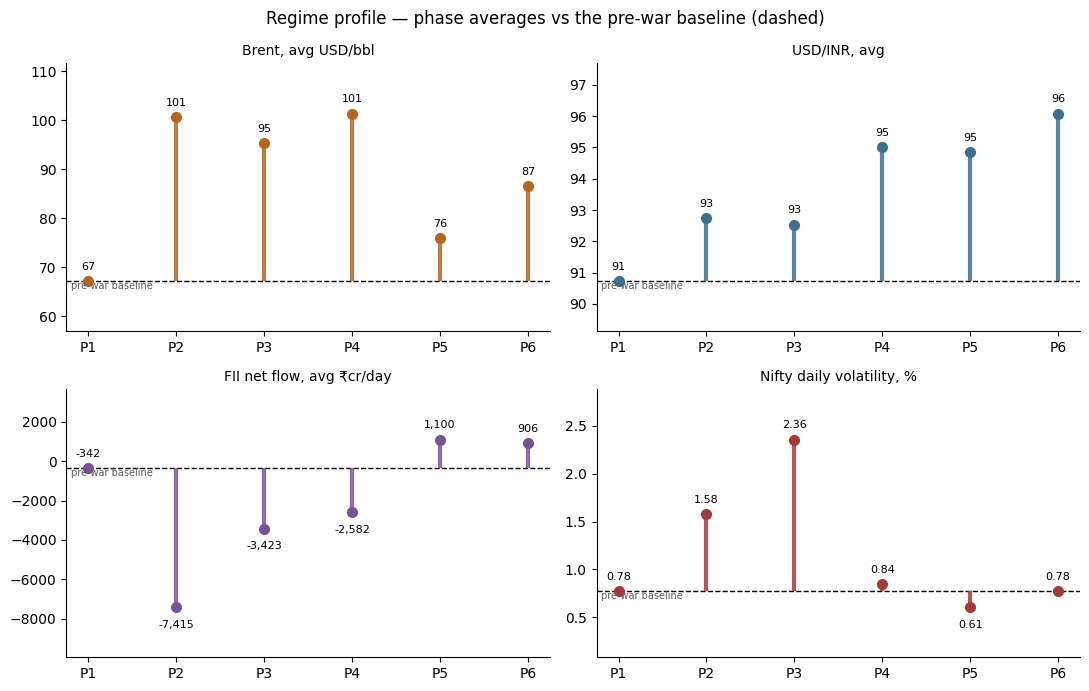

In [6]:
%matplotlib inline
# Regime profile: four defining variables, each phase against the pre-war baseline.
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
specs = [('brent_avg_usd',    'Brent, avg USD/bbl',        '#b5651d'),
         ('usd_inr_avg',      'USD/INR, avg',              '#3f6f8f'),
         ('fii_avg_daily_cr', 'FII net flow, avg ₹cr/day', '#7a5195'),
         ('nifty_vol_daily_pct', 'Nifty daily volatility, %', '#a33b3b')]
labels = [f'P{r.phase_id}' for r in rs.itertuples()]
x = range(len(labels))
for ax, (col, title, colour) in zip(axes.ravel(), specs):
    vals = rs[col].values.astype(float)
    base = vals[0]                                   # phase 1 = pre-war baseline
    # Stems run FROM the baseline TO the phase value, so the drawn length is the
    # deviation from normal. (Bars from zero would either hide the USD/INR move or
    # need a truncated axis, which misleads for bars; stems + dots do not.)
    ax.axhline(base, color='k', ls='--', lw=1)
    ax.vlines(x, base, vals, color=colour, lw=3, alpha=.85)
    ax.plot(x, vals, 'o', color=colour, ms=7)
    ax.set_xticks(list(x)); ax.set_xticklabels(labels)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:,.0f}' if abs(v) > 20 else f'{v:,.2f}', (i, v),
                    textcoords='offset points', xytext=(0, 8 if v >= base else -15),
                    ha='center', fontsize=8)
    ax.text(0.01, base, 'pre-war baseline', transform=ax.get_yaxis_transform(),
            va='top', ha='left', fontsize=7, color='0.35')
    ax.set_title(title, fontsize=10); ax.margins(y=.30)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Regime profile — phase averages vs the pre-war baseline (dashed)', fontsize=12)
plt.tight_layout(); plt.show()

**How to read this chart:** four panels, one per defining variable; six points each, one per war phase (P1 = pre-war baseline). The **dashed line is the phase-1 value** — the "normal" the stress index will measure everything against — and each **stem is drawn from that line to the phase's value, so stem length is literally the deviation from normal**. That gap *is* the raw material of the index: Component 2 converts exactly these distances into z-scores by dividing them by the baseline standard deviation.

The panels also show why **one variable is not enough**. Oil peaks in P4, foreign selling peaks in P2, volatility peaks in P3, and the rupee is weakest in P6 — no single series identifies the worst regime on its own. That is the case for a composite index, made visually before any index is built.

### Finding

The six war phases are quantitatively distinct regimes, not just date labels. Against a pre-war baseline of **Brent $67 / USD-INR 90.7 / FII −₹342 cr per day / 0.78% daily Nifty volatility**, the acute-war regime runs at **Brent $100.6, FII −₹7,415 cr per day and double the volatility** (Nifty −8.2% across the phase, −₹1.56 lakh crore of foreign selling in 23 sessions), while the blockade regime holds the *highest average oil of the war* with the market already repriced (Nifty −1.8%) and the de-escalation regime flips flows positive for the first time. Critically, **no single variable ranks the regimes on its own** — oil peaks in phase 4, outflows in phase 2, volatility in phase 3, the weakest rupee in phase 6 — which is the empirical case for the composite stress index built in Component 2.

**Carried forward to Component 2:** phase 1 supplies the baseline mean *and* standard deviation for four of the five index components (oil, rupee, flows, equity). The fifth — the **10Y G-Sec yield — has zero pre-war observations**, so its z-score cannot be computed against a phase-1 reference distribution as the milestone plan specifies. That must be resolved (source a real yield history, or drop to a documented four-component index) before the index is constructed.